In [33]:
import os
import re
from functorch.dim import dot
import json
from collections import defaultdict
import pandas as pd
from sentence_transformers import SentenceTransformer
import numpy as np
from tqdm import tqdm
import dotenv
import tiktoken

dotenv.load_dotenv()  # Load environment variables from .env file

# Path to the processed Polish dataset root
base_path = '../data/raw/polish_dataset_7_v3'

# Regex to match cluster folders like 'cluster_A', 'cluster_B', etc.
cluster_pattern = re.compile(r'^cluster_([A-Z])$')

doc_chunks = defaultdict(list[str])

# Iterate through each cluster folder
for cluster_name in os.listdir(base_path):
    cluster_match = cluster_pattern.match(cluster_name)
    if not cluster_match:
        # print(1)
        continue
    cluster_letter = cluster_match.group(1)
    cluster_path = os.path.join(base_path, cluster_name)
    if not os.path.isdir(cluster_path):
        continue
    # Each cluster contains dataset folders
    for dataset_name in os.listdir(cluster_path):
        dataset_path = os.path.join(cluster_path, dataset_name)
        if not os.path.isdir(dataset_path):
            continue
        chunks_file = os.path.join(dataset_path, 'chunks.jsonl')
        if not os.path.isfile(chunks_file):
            continue
        # Read chunks.jsonl and group by doc_id = <cluster_letter>-<dataset_name>
        doc_id = f"{cluster_letter}-{dataset_name}"
        with open(chunks_file, 'r', encoding='utf-8') as f:
            for line in f:
                entry = json.loads(line)
                chunk_text = entry['chunk']
                doc_chunks[doc_id].append(chunk_text)

print(f"Loaded {len(doc_chunks)} documents.")
for doc_id, chunks in doc_chunks.items():
    print(f"{doc_id}: {len(chunks)} chunks")


device = 'mps'


Loaded 7 documents.
T-financing_education: 1015 chunks
A-military: 2305 chunks
A-classified_information: 795 chunks
A-police: 2919 chunks
B-social_insurance_act: 2015 chunks
B-social_assistance_act: 1805 chunks
B-healthcare: 4344 chunks


# Sparse (ABANDON)

In [38]:
from FlagEmbedding import BGEM3FlagModel

model = BGEM3FlagModel('BAAI/bge-m3',  use_fp16=True, device=device) # Setting use_fp16 to True speeds up computation with a slight performance degradation


Fetching 30 files: 100%|██████████| 30/30 [00:00<00:00, 202623.38it/s]


In [39]:

sentences_1 = ["What is BGE M3?", "Defination of BM25"]
sentences_2 = ["BGE M3 is an embedding model supporting dense retrieval, lexical matching and multi-vector interaction.", 
               "BM25 is a bag-of-words retrieval function that ranks a set of documents based on the query terms appearing in each document", "Defination of BM25"]

output_1 = model.encode(sentences_1, return_dense=False, return_sparse=True, return_colbert_vecs=False)
output_2 = model.encode(sentences_2, return_dense=False, return_sparse=True, return_colbert_vecs=False)

# you can see the weight for each token:
print(model.convert_id_to_token(output_1['lexical_weights']))
# [{'What': 0.08356, 'is': 0.0814, 'B': 0.1296, 'GE': 0.252, 'M': 0.1702, '3': 0.2695, '?': 0.04092}, 
#  {'De': 0.05005, 'fin': 0.1368, 'ation': 0.04498, 'of': 0.0633, 'BM': 0.2515, '25': 0.3335}]


# compute the scores via lexical mathcing
lexical_scores = model.compute_lexical_matching_score(output_1['lexical_weights'][0], output_2['lexical_weights'][0])
print(lexical_scores)
# 0.19554901123046875

print(model.compute_lexical_matching_score(output_1['lexical_weights'][0], output_1['lexical_weights'][1]))
print(model.compute_lexical_matching_score(output_1['lexical_weights'][1], output_2['lexical_weights'][2]))
# 0.0


You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


[{'What': np.float16(0.0835), 'is': np.float16(0.0814), 'B': np.float16(0.1296), 'GE': np.float16(0.252), 'M': np.float16(0.17), '3': np.float16(0.2695), '?': np.float16(0.04077)}, {'De': np.float16(0.0502), 'fin': np.float16(0.137), 'ation': np.float16(0.04514), 'of': np.float16(0.06335), 'BM': np.float16(0.2515), '25': np.float16(0.3333)}]
0.1954
0
0.2018


In [46]:

sum(model.convert_id_to_token(output_1['lexical_weights'])[0].values())





np.float16(1.026)

In [ ]:
import math


def sparse_norm(sv: dict) -> float:
    return math.sqrt(sum(w**2 for w in sv.values()))

def cosine_sparse(sv1: dict, sv2: dict) -> float:
    dot = sum(sv1[k] * sv2[k] for k in sv1 if k in sv2)
    return dot / (sparse_norm(sv1) * sparse_norm(sv2) + 1e-9)



cosine_sparse(output_1['lexical_weights'][0], output_2['lexical_weights'][0])

np.float16(0.5684)

In [16]:
from collections import defaultdict

def average_sparse_vectors(sparse_dicts: list[dict]) -> dict:
    acc = defaultdict(float)
    n = len(sparse_dicts)
    for sv in sparse_dicts:
        for token_id, weight in sv.items():
            acc[token_id] += weight / n
    return dict(acc)

In [17]:

# Compute average embedding for each document
doc_embeddings = {}
for doc_id, chunks in tqdm(doc_chunks.items()):
    chunk_embs = model.encode(chunks, return_dense=False, return_sparse=True, return_colbert_vecs=False)
    avg_emb = average_sparse_vectors(chunk_embs['lexical_weights'])
    doc_embeddings[doc_id] = avg_emb

print(f"Computed embeddings for {len(doc_embeddings)} documents.")


100%|██████████| 9/9 [07:02<00:00, 46.90s/it]

Computed embeddings for 9 documents.


In [19]:
# compute the lexical similarity matrix using model.lexical_matching_score
doc_ids = sorted(doc_embeddings.keys())
sim_matrix = np.zeros((len(doc_ids), len(doc_ids)))
for i in tqdm(range(len(doc_ids))):
    for j in range(i, len(doc_ids)):
        score = cosine_sparse(doc_embeddings[doc_ids[i]], doc_embeddings[doc_ids[j]])
        sim_matrix[i, j] = score
        sim_matrix[j, i] = score  # Symmetric matrix
# Prepare doc_id list and embedding matrix

# Create a DataFrame for pretty display
sim_df = pd.DataFrame(sim_matrix, index=doc_ids, columns=doc_ids)

# Display the similarity table
sim_df.round(3)

100%|██████████| 9/9 [00:00<00:00, 110.75it/s]


,A-civil_code,A-environmental_protection,A-healthcare,B-classified_information,B-military,B-police,Q-education_law,Q-highereducation_science,T-financing_education
A-civil_code,1.000,0.463,0.428,0.336,0.406,0.410,0.376,0.457,0.290
A-environmental_protection,0.463,1.000,0.621,0.496,0.520,0.560,0.580,0.639,0.410
A-healthcare,0.428,0.621,1.000,0.467,0.500,0.536,0.556,0.605,0.392
B-classified_information,0.336,0.496,0.467,1.000,0.429,0.475,0.428,0.480,0.285
B-military,0.406,0.520,0.500,0.429,1.000,0.597,0.493,0.542,0.324
B-police,0.410,0.560,0.536,0.475,0.597,1.000,0.521,0.598,0.348
Q-education_law,0.376,0.580,0.556,0.428,0.493,0.521,1.000,0.645,0.660
Q-highereducation_science,0.457,0.639,0.605,0.480,0.542,0.598,0.645,1.000,0.456
T-financing_education,0.290,0.410,0.392,0.285,0.324,0.348,0.660,0.456,1.000


# Computing simple dense

In [34]:
# Load the sentence transformer model
# model_name = 'BAAI/bge-m3'
model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

# set the device to GPU if available otherwise mps if available otherwise CPU


model = SentenceTransformer(model_name, device=device)

In [35]:
# USING SENTEN
# Compute average embedding for each document
doc_embeddings = {}
for doc_id, chunks in tqdm(doc_chunks.items()):
    chunk_embs = model.encode(chunks, show_progress_bar=True, device=device)
    avg_emb = np.mean(chunk_embs, axis=0)
    doc_embeddings[doc_id] = avg_emb

print(f"Computed embeddings for {len(doc_embeddings)} documents.")
embedding_dim = next(iter(doc_embeddings.values())).shape[0]
print(f"Embedding dimension: {embedding_dim}")


  0%|          | 0/7 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:17<00:00,  2.44s/it]

Computed embeddings for 7 documents.
Embedding dimension: 384


In [36]:
from sklearn.metrics.pairwise import cosine_similarity

# Prepare doc_id list and embedding matrix
doc_ids = sorted(doc_embeddings.keys())
emb_matrix = np.stack([doc_embeddings[doc_id] for doc_id in doc_ids])

# Compute cosine similarity matrix
sim_matrix = cosine_similarity(emb_matrix)

# Create a DataFrame for pretty display
sim_df = pd.DataFrame(sim_matrix, index=doc_ids, columns=doc_ids)

# Display the similarity table
sim_df.round(3)

,A-classified_information,A-military,A-police,B-healthcare,B-social_assistance_act,B-social_insurance_act,T-financing_education
A-classified_information,1.000,0.802,0.904,0.848,0.787,0.816,0.628
A-military,0.802,1.000,0.837,0.785,0.769,0.744,0.649
A-police,0.904,0.837,1.000,0.835,0.805,0.801,0.671
B-healthcare,0.848,0.785,0.835,1.000,0.914,0.947,0.740
B-social_assistance_act,0.787,0.769,0.805,0.914,1.000,0.903,0.769
B-social_insurance_act,0.816,0.744,0.801,0.947,0.903,1.000,0.726
T-financing_education,0.628,0.649,0.671,0.740,0.769,0.726,1.000


# Visualisation

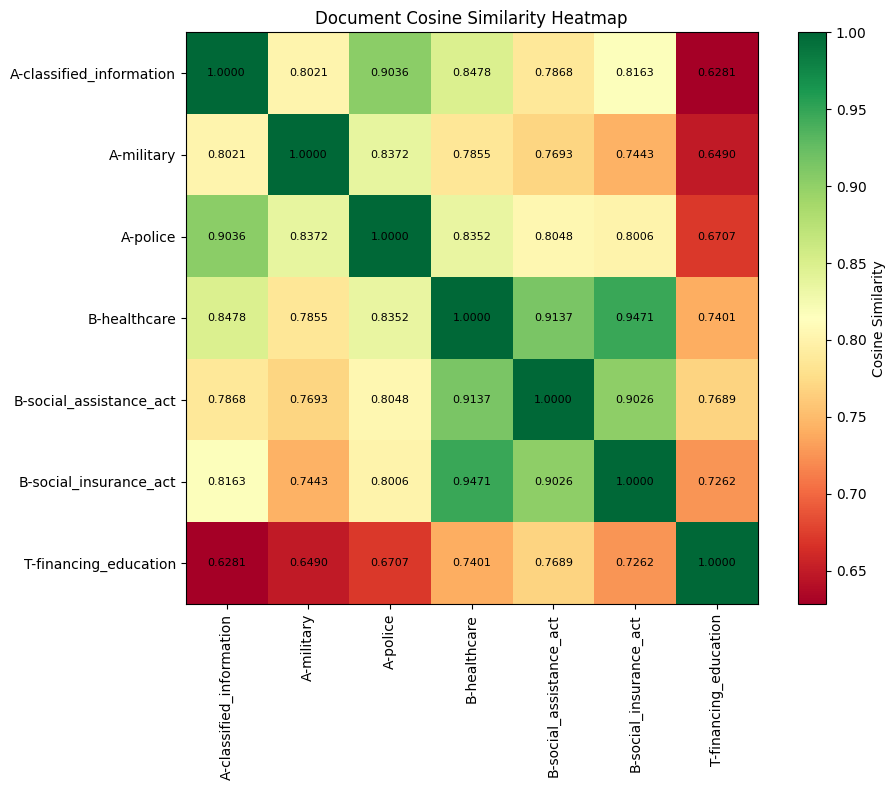

In [37]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 8))
# Set vmin to the minimum value in the similarity matrix
vmin = sim_df.values.min()
vmax = 1
im = plt.imshow(sim_df, cmap='RdYlGn', vmin=vmin, vmax=vmax)

# Overlay the values
for i in range(sim_df.shape[0]):
    for j in range(sim_df.shape[1]):
        plt.text(j, i, f"{sim_df.iloc[i, j]:.4f}", ha="center", va="center", color="black", fontsize=8)

plt.colorbar(im, label='Cosine Similarity')
plt.xticks(ticks=np.arange(len(doc_ids)), labels=doc_ids, rotation=90)
plt.yticks(ticks=np.arange(len(doc_ids)), labels=doc_ids)
plt.title("Document Cosine Similarity Heatmap")
plt.tight_layout()
plt.show()